---
## Exploratory Data Analysis
Load the cleaned CSV and produce visualizations that reveal patterns in lead quality.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---------- Load cleaned data ----------
df = pd.read_csv("leads_cleaned.csv")
df["lead_date"] = pd.to_datetime(df["lead_date"])

# ---------- Global style ----------
sns.set_theme(style="whitegrid", font_scale=1.1)
PALETTE = {"Low": "#4C72B0", "Medium": "#55A868", "High": "#C44E52"}
BAND_ORDER = ["Low", "Medium", "High"]

os.makedirs("figures", exist_ok=True)

print("Cleaned data loaded:", df.shape)
print("lead_date dtype:", df["lead_date"].dtype)
print("Date range:", df["lead_date"].min(), "to", df["lead_date"].max())

Cleaned data loaded: (1143, 15)
lead_date dtype: datetime64[ns]
Date range: 2025-12-04 00:00:00 to 2026-03-04 00:00:00


### 1. Class Distribution: Is our target balanced?
A simple count of each `expected_profit_band` value tells us whether we have enough examples of every class to train a fair model.

/var/folders/fq/kfy7z0qs2lvf8czf1dkhdr300000gn/T/ipykernel_99566/2381233868.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


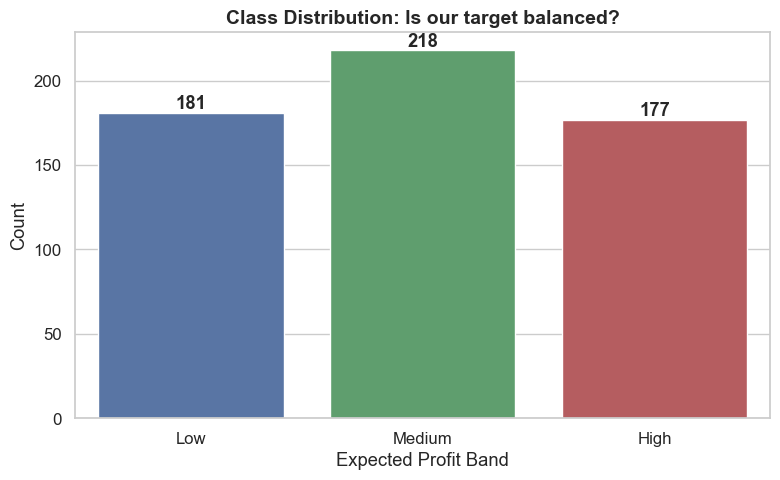

Key takeaway: The three profit bands are roughly balanced, so class imbalance is not a major concern for modeling.


In [2]:
fig, ax = plt.subplots(figsize=(8, 5))
data = df.dropna(subset=["expected_profit_band"])
sns.countplot(
    data=data,
    x="expected_profit_band",
    order=BAND_ORDER,
    palette=PALETTE,
    ax=ax,
)
ax.set_title("Class Distribution: Is our target balanced?", fontsize=14, fontweight="bold")
ax.set_xlabel("Expected Profit Band")
ax.set_ylabel("Count")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
               ha="center", va="bottom", fontweight="bold")
plt.tight_layout()
fig.savefig("figures/01_class_distribution.png", dpi=150)
plt.show()

print("Key takeaway: The three profit bands are roughly balanced, so class imbalance is not a major concern for modeling.")

### 2. Does job size predict profit band?
A boxplot of `estimated_job_size_sqft` grouped by `expected_profit_band` shows whether larger jobs tend to fall into higher profit tiers.

/var/folders/fq/kfy7z0qs2lvf8czf1dkhdr300000gn/T/ipykernel_99566/838018117.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


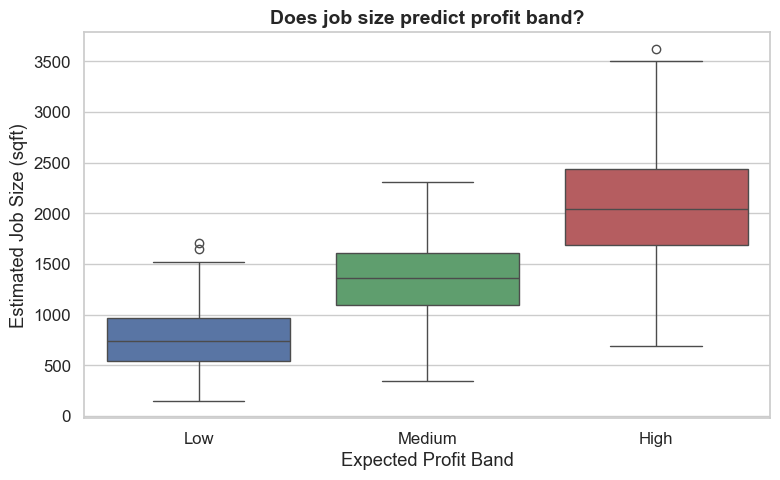

Key takeaway: Higher profit-band leads have clearly larger median job sizes, making sqft a strong predictive feature.


In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
data = df.dropna(subset=["expected_profit_band", "estimated_job_size_sqft"])
sns.boxplot(
    data=data,
    x="expected_profit_band",
    y="estimated_job_size_sqft",
    order=BAND_ORDER,
    palette=PALETTE,
    ax=ax,
)
ax.set_title("Does job size predict profit band?", fontsize=14, fontweight="bold")
ax.set_xlabel("Expected Profit Band")
ax.set_ylabel("Estimated Job Size (sqft)")
plt.tight_layout()
fig.savefig("figures/02_jobsize_vs_profit.png", dpi=150)
plt.show()

print("Key takeaway: Higher profit-band leads have clearly larger median job sizes, making sqft a strong predictive feature.")

### 3. Do homeowners generate higher value leads?
A grouped bar chart of `homeowner_status` vs `expected_profit_band` reveals whether ownership type influences lead quality.

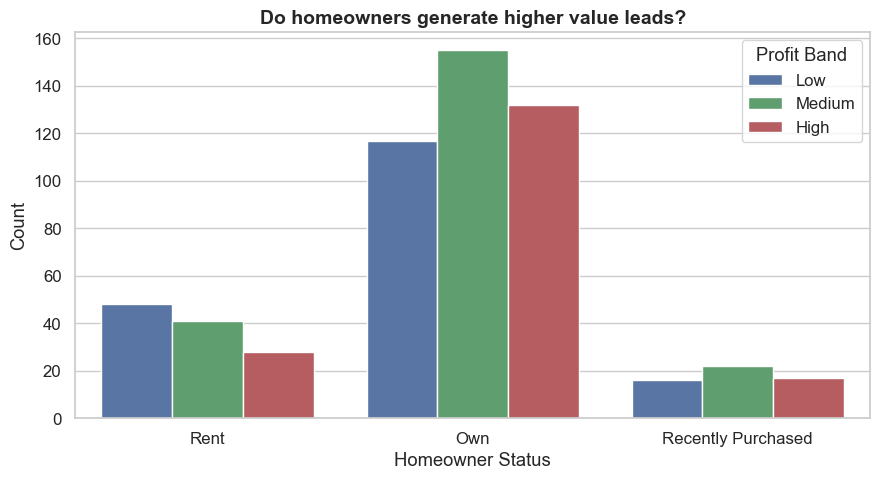

Key takeaway: Homeowners ('Own') dominate the dataset and produce the most High-profit leads in absolute numbers.


In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
data = df.dropna(subset=["expected_profit_band"])
sns.countplot(
    data=data,
    x="homeowner_status",
    hue="expected_profit_band",
    hue_order=BAND_ORDER,
    palette=PALETTE,
    ax=ax,
)
ax.set_title("Do homeowners generate higher value leads?", fontsize=14, fontweight="bold")
ax.set_xlabel("Homeowner Status")
ax.set_ylabel("Count")
ax.legend(title="Profit Band")
plt.tight_layout()
fig.savefig("figures/03_homeowner_vs_profit.png", dpi=150)
plt.show()

print("Key takeaway: Homeowners ('Own') dominate the dataset and produce the most High-profit leads in absolute numbers.")

### 4. Which acquisition channel produces the best leads?
A grouped bar chart of `referral_source` vs `expected_profit_band` highlights which marketing channels bring in the most valuable leads.

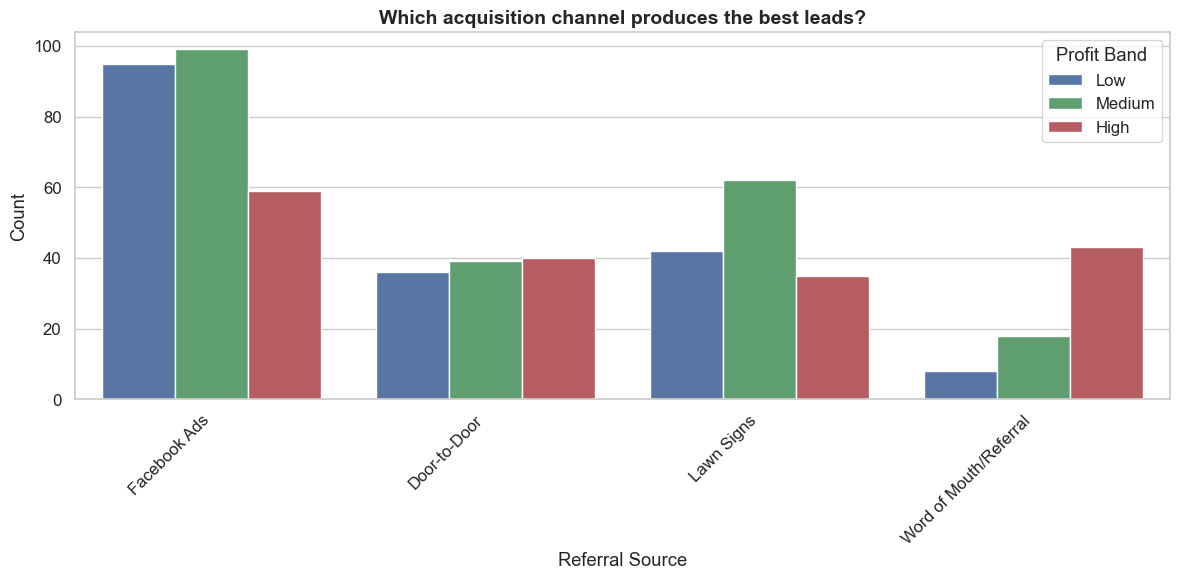

Key takeaway: Facebook Ads drives the highest volume of leads across all bands, but Word of Mouth/Referral has a proportionally higher share of High-profit leads.


In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
data = df.dropna(subset=["expected_profit_band"])
sns.countplot(
    data=data,
    x="referral_source",
    hue="expected_profit_band",
    hue_order=BAND_ORDER,
    palette=PALETTE,
    ax=ax,
)
ax.set_title("Which acquisition channel produces the best leads?", fontsize=14, fontweight="bold")
ax.set_xlabel("Referral Source")
ax.set_ylabel("Count")
ax.legend(title="Profit Band")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig.savefig("figures/04_referral_vs_profit.png", dpi=150)
plt.show()

print("Key takeaway: Facebook Ads drives the highest volume of leads across all bands, but Word of Mouth/Referral has a proportionally higher share of High-profit leads.")

### 5. Does urgency correlate with lead quality?
A grouped bar chart of `requested_timeline` vs `expected_profit_band` checks whether leads who need faster timelines are also higher-value.

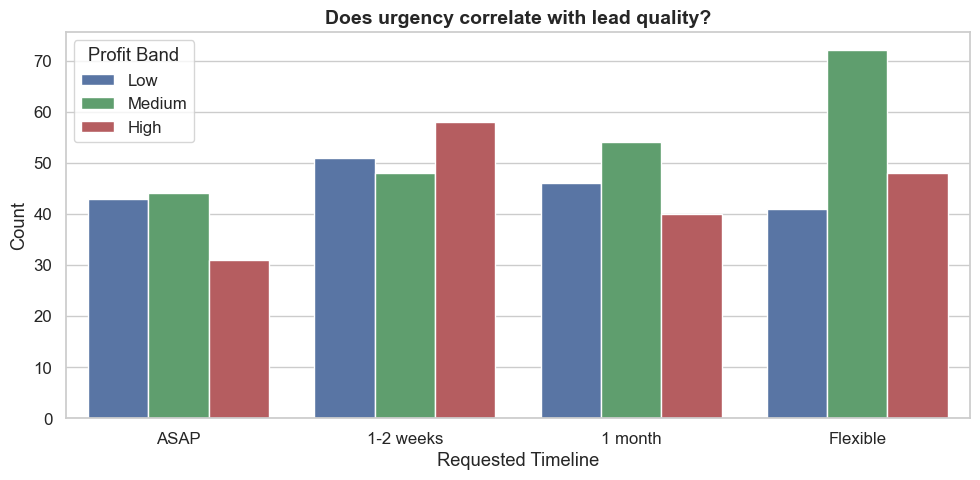

Key takeaway: Lead quality is fairly evenly spread across timelines, suggesting urgency alone is not a strong predictor of profit band.


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
data = df.dropna(subset=["expected_profit_band"])
timeline_order = ["ASAP", "1-2 weeks", "1 month", "Flexible"]
sns.countplot(
    data=data,
    x="requested_timeline",
    hue="expected_profit_band",
    hue_order=BAND_ORDER,
    palette=PALETTE,
    order=timeline_order,
    ax=ax,
)
ax.set_title("Does urgency correlate with lead quality?", fontsize=14, fontweight="bold")
ax.set_xlabel("Requested Timeline")
ax.set_ylabel("Count")
ax.legend(title="Profit Band")
plt.tight_layout()
fig.savefig("figures/05_timeline_vs_profit.png", dpi=150)
plt.show()

print("Key takeaway: Lead quality is fairly evenly spread across timelines, suggesting urgency alone is not a strong predictor of profit band.")

### 6. Numeric Feature Correlations
A correlation heatmap of the numeric columns (`estimated_job_size_sqft`, `distance_to_queens_km`) against the encoded target shows which numeric features are most linearly associated with profit band.

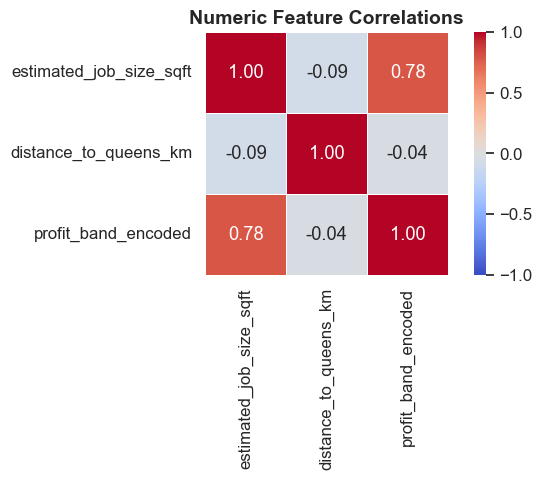

Key takeaway: Estimated job size has a strong positive correlation with profit band, while distance to Queens shows little to no linear relationship.


In [7]:
fig, ax = plt.subplots(figsize=(7, 5))

data = df.dropna(subset=["expected_profit_band", "estimated_job_size_sqft", "distance_to_queens_km"]).copy()
label_map = {"Low": 0, "Medium": 1, "High": 2}
data["profit_band_encoded"] = data["expected_profit_band"].map(label_map)

corr_cols = ["estimated_job_size_sqft", "distance_to_queens_km", "profit_band_encoded"]
corr = data[corr_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Numeric Feature Correlations", fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig("figures/06_correlation_heatmap.png", dpi=150)
plt.show()

print("Key takeaway: Estimated job size has a strong positive correlation with profit band, while distance to Queens shows little to no linear relationship.")

### 7. Which neighbourhoods produce the highest value leads?
A grouped bar chart of `neighbourhood` vs `expected_profit_band` reveals geographic hotspots for high-value leads.

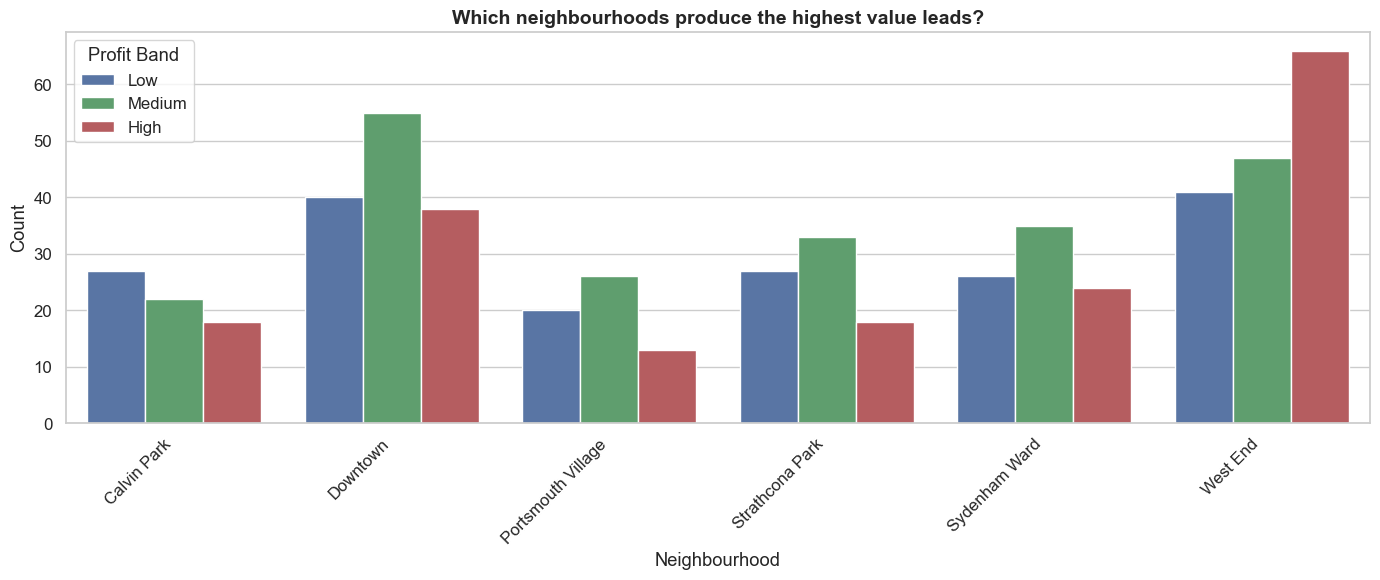

Key takeaway: Downtown and West End generate the most leads overall, but the ratio of High-to-Low profit leads varies meaningfully by neighbourhood.


In [8]:
fig, ax = plt.subplots(figsize=(14, 6))
data = df.dropna(subset=["expected_profit_band"])
neighbourhood_order = sorted(data["neighbourhood"].unique())
sns.countplot(
    data=data,
    x="neighbourhood",
    hue="expected_profit_band",
    hue_order=BAND_ORDER,
    palette=PALETTE,
    order=neighbourhood_order,
    ax=ax,
)
ax.set_title("Which neighbourhoods produce the highest value leads?", fontsize=14, fontweight="bold")
ax.set_xlabel("Neighbourhood")
ax.set_ylabel("Count")
ax.legend(title="Profit Band")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig.savefig("figures/07_neighbourhood_vs_profit.png", dpi=150)
plt.show()

print("Key takeaway: Downtown and West End generate the most leads overall, but the ratio of High-to-Low profit leads varies meaningfully by neighbourhood.")